# Hybrid Fusion Experiment: current KG reranker + BGEGemma

This notebook tests a simple late-fusion hybrid between:

- the current best KG reranker: `SVD sim-only @512` with `alpha = 0.30`
- the `BGEGemma` LLM reranker

Both systems score the same dense top-100 candidate set. Their per-query scores are min-max normalized and fused as:

`hybrid = beta * current + (1 - beta) * bge`

The goal is to see whether BGEGemma recovers some of the queries where the KG reranker underperforms while preserving the KG reranker's overall advantage.

In [1]:
import os
import re
import unicodedata
from pathlib import Path
from typing import Dict, List, Tuple

import faiss
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyterrier as pt
import torch
from scipy.sparse import csr_matrix
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize
from transformers import AutoModelForCausalLM, AutoTokenizer

os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("VECLIB_MAXIMUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

if not pt.java.started():
    pt.java.init()

def l2_normalize_rows(M: np.ndarray) -> np.ndarray:
    M = M.astype(np.float32, copy=False)
    denom = np.linalg.norm(M, axis=1, keepdims=True) + 1e-12
    return (M / denom).astype(np.float32)

def ensure_run(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["qid"] = df["qid"].astype(str)
    df["docno"] = df["docno"].astype(str)
    if "score" not in df.columns:
        df["score"] = 0.0
    df["score"] = df["score"].astype(float)
    if "rank" not in df.columns:
        df = df.sort_values(["qid", "score"], ascending=[True, False])
        df["rank"] = df.groupby("qid").cumcount() + 1
    return df

_ws_re = re.compile(r"\s+")
_tags_re = re.compile(r"<[^>]+>")

def normalize_text(s: str) -> str:
    if s is None:
        return ""
    s = str(s)
    s = _tags_re.sub(" ", s)
    s = unicodedata.normalize("NFKC", s)
    s = s.lower()
    s = re.sub(r"[^0-9a-zA-ZäöüßÄÖÜẞ]+", " ", s)
    s = _ws_re.sub(" ", s).strip()
    return s

def safe_concat(parts):
    clean = []
    for p in parts:
        if p is None:
            continue
        p = str(p)
        if p.strip() in ("", "N/A", "nan"):
            continue
        clean.append(p)
    return " ".join(clean)

def build_doc_text(row: pd.Series) -> str:
    return safe_concat([row.get("question"), row.get("choices_processed")])


/Users/user/miniconda3/envs/KG-re-ranking/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Java started and loaded: pyterrier.java.colab, pyterrier.java, pyterrier.java.24, pyterrier.terrier.java [version=5.11 (build: craig.macdonald 2025-01-13 21:29), helper_version=0.0.8]


In [2]:
PROJECT_ROOT = Path("/Users/user/Submissions/BEA-2026").resolve()
QB_PATH = PROJECT_ROOT / "qbank.csv"
QUERIES_PATH = PROJECT_ROOT / "queries.csv"
QRELS_PATH = PROJECT_ROOT / "qrels.tsv"

OUT_DIR = PROJECT_ROOT / "artifacts" / "kg_bge_hybrid"
OUT_DIR.mkdir(parents=True, exist_ok=True)

CACHE_DIR = PROJECT_ROOT / "artifacts" / "svd_ablation"

DENSE_MODEL = "deutsche-telekom/gbert-large-paraphrase-cosine"
BGE_MODEL = "BAAI/bge-reranker-v2-gemma"
BGE_BATCH = 4
BGE_MAX_LENGTH = 512

K_CAND = 100
K_FINAL = 50
RANDOM_STATE = 42
SVD_DIM = 512
ALPHA = 0.30
BETAS = [round(x, 2) for x in np.arange(0.0, 1.0001, 0.05)]

print("PROJECT_ROOT:", PROJECT_ROOT)
print("OUT_DIR:", OUT_DIR)
print("BETAS:", BETAS)

qb = pd.read_csv(QB_PATH).fillna("N/A")
queries = pd.read_csv(QUERIES_PATH).fillna("")
qrels = pd.read_csv(QRELS_PATH, sep="\t").fillna(0)

qb["docno"] = qb["test_item_id"].astype(str)
qb["raw_text"] = qb.apply(build_doc_text, axis=1)
qb["text"] = qb["raw_text"].map(normalize_text)
corpus = qb[["docno", "text"]].copy()

topics = queries.rename(columns={"queries": "query"})[["qid", "query"]].copy()
topics["qid"] = topics["qid"].astype(str)
topics["query"] = topics["query"].astype(str).map(normalize_text)

qrels = qrels.rename(columns={"rel": "label"})[["qid", "docno", "label"]].copy()
qrels["qid"] = qrels["qid"].astype(str)
qrels["docno"] = qrels["docno"].astype(str)
qrels["label"] = qrels["label"].astype(int)


PROJECT_ROOT: /Users/user/Submissions/BEA-2026
OUT_DIR: /Users/user/Submissions/BEA-2026/artifacts/kg_bge_hybrid
BETAS: [np.float64(0.0), np.float64(0.05), np.float64(0.1), np.float64(0.15), np.float64(0.2), np.float64(0.25), np.float64(0.3), np.float64(0.35), np.float64(0.4), np.float64(0.45), np.float64(0.5), np.float64(0.55), np.float64(0.6), np.float64(0.65), np.float64(0.7), np.float64(0.75), np.float64(0.8), np.float64(0.85), np.float64(0.9), np.float64(0.95), np.float64(1.0)]


In [3]:
class FaissDenseRetriever(pt.Transformer):
    def __init__(self, corpus_df: pd.DataFrame, model_name: str, topk: int):
        super().__init__()
        self.topk = int(topk)
        cdf = corpus_df[["docno", "text"]].copy()
        cdf["docno"] = cdf["docno"].astype(str)
        cdf["text"] = cdf["text"].astype(str)
        self.docnos = cdf["docno"].tolist()
        self.st = SentenceTransformer(model_name, device="cpu")
        xdoc = self.st.encode(
            cdf["text"].tolist(),
            convert_to_numpy=True,
            normalize_embeddings=True,
            show_progress_bar=True,
        ).astype("float32")
        self.index = faiss.IndexFlatIP(xdoc.shape[1])
        self.index.add(xdoc)

    def transform(self, topics_df: pd.DataFrame) -> pd.DataFrame:
        qids = topics_df["qid"].astype(str).tolist()
        qs = topics_df["query"].astype(str).tolist()
        q = self.st.encode(
            qs,
            convert_to_numpy=True,
            normalize_embeddings=True,
            show_progress_bar=False,
        ).astype("float32")
        scores, idxs = self.index.search(q, self.topk)
        rows = []
        for i, qid in enumerate(qids):
            for rank, (j, sc) in enumerate(zip(idxs[i], scores[i]), start=1):
                if j < 0:
                    continue
                rows.append({"qid": qid, "docno": self.docnos[j], "score": float(sc), "rank": int(rank)})
        return pd.DataFrame(rows)

class StaticRunSource(pt.Transformer):
    def __init__(self, run_df: pd.DataFrame):
        super().__init__()
        self.run_df = ensure_run(run_df)

    def transform(self, topics_df: pd.DataFrame) -> pd.DataFrame:
        return self.run_df.copy()

class KGReranker(pt.Transformer):
    def __init__(self, qid2vec: Dict[str, np.ndarray], docno2vec: Dict[str, np.ndarray], alpha: float = 0.5):
        super().__init__()
        self.qid2vec = qid2vec
        self.docno2vec = docno2vec
        self.alpha = float(alpha)
        self.dim = int(next(iter(docno2vec.values())).shape[0])
        self.zero = np.zeros(self.dim, dtype=np.float32)

    def transform(self, df: pd.DataFrame) -> pd.DataFrame:
        df = ensure_run(df)
        out = df.copy()
        out["orig_score"] = out["score"].astype(float)
        Q = np.vstack([self.qid2vec.get(q, self.zero) for q in out["qid"]]).astype(np.float32)
        D = np.vstack([self.docno2vec.get(d, self.zero) for d in out["docno"]]).astype(np.float32)
        kg = (l2_normalize_rows(Q) * l2_normalize_rows(D)).sum(axis=1).astype(np.float32)
        out["kg_score"] = kg.astype(float)
        out["score"] = ((1.0 - self.alpha) * out["kg_score"] + self.alpha * out["orig_score"]).astype(float)
        out = out.sort_values(["qid", "score"], ascending=[True, False])
        out["rank"] = out.groupby("qid").cumcount() + 1
        return out

def build_llm_inputs(pairs, tokenizer, prompt=None, max_length=512):
    if prompt is None:
        prompt = (
            "Given a query A and a passage B, determine whether the passage contains "
            "an answer to the query by providing a prediction of either 'Yes' or 'No'."
        )
    sep = "\n"
    prompt_inputs = tokenizer(prompt, return_tensors=None, add_special_tokens=False)["input_ids"]
    sep_inputs = tokenizer(sep, return_tensors=None, add_special_tokens=False)["input_ids"]
    inputs = []
    for query, passage in pairs:
        query_inputs = tokenizer(
            f"A: {query}",
            return_tensors=None,
            add_special_tokens=False,
            max_length=max_length * 3 // 4,
            truncation=True,
        )
        passage_inputs = tokenizer(
            f"B: {passage}",
            return_tensors=None,
            add_special_tokens=False,
            max_length=max_length,
            truncation=True,
        )
        item = tokenizer.prepare_for_model(
            [tokenizer.bos_token_id] + query_inputs["input_ids"],
            sep_inputs + passage_inputs["input_ids"],
            truncation="only_second",
            max_length=max_length,
            padding=False,
            return_attention_mask=False,
            return_token_type_ids=False,
            add_special_tokens=False,
        )
        item["input_ids"] = item["input_ids"] + sep_inputs + prompt_inputs
        item["attention_mask"] = [1] * len(item["input_ids"])
        inputs.append(item)
    return tokenizer.pad(
        inputs,
        padding=True,
        max_length=max_length + len(sep_inputs) + len(prompt_inputs),
        pad_to_multiple_of=8,
        return_tensors="pt",
    )

class BGEGemmaReranker(pt.Transformer):
    def __init__(self, corpus_df: pd.DataFrame, model_name: str, batch_size: int = 4, max_length: int = 512):
        super().__init__()
        cdf = corpus_df[["docno", "text"]].copy()
        cdf["docno"] = cdf["docno"].astype(str)
        cdf["text"] = cdf["text"].astype(str)
        self.docno2text = dict(zip(cdf["docno"], cdf["text"]))
        self.batch_size = int(batch_size)
        self.max_length = int(max_length)
        if torch.cuda.is_available():
            self.device = "cuda"
        elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
            self.device = "mps"
        else:
            self.device = "cpu"
        model_kwargs = {"low_cpu_mem_usage": True}
        if self.device in {"cuda", "mps"}:
            model_kwargs["dtype"] = torch.float16
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModelForCausalLM.from_pretrained(model_name, **model_kwargs).to(self.device)
        self.model.eval()
        self.yes_loc = self.tokenizer("Yes", add_special_tokens=False)["input_ids"][0]
        print(f"Loaded {model_name} on {self.device}")

    def _score_pairs(self, pairs):
        scores = []
        for start in range(0, len(pairs), self.batch_size):
            batch_pairs = pairs[start:start + self.batch_size]
            inputs = build_llm_inputs(batch_pairs, self.tokenizer, max_length=self.max_length)
            inputs = {k: v.to(self.device) for k, v in inputs.items()}
            with torch.no_grad():
                logits = self.model(**inputs, return_dict=True).logits[:, -1, self.yes_loc]
            batch_scores = logits.float().detach().cpu().numpy().astype(float).tolist()
            scores.extend(batch_scores)
            del inputs, logits
            if self.device == "cuda":
                torch.cuda.empty_cache()
            elif self.device == "mps":
                torch.mps.empty_cache()
        return np.asarray(scores, dtype=float)

    def transform(self, df: pd.DataFrame) -> pd.DataFrame:
        df = ensure_run(df)
        if "query" not in df.columns:
            raise ValueError("BGEGemmaReranker needs query column, merge topics first")
        out_groups = []
        for qid, g in df.groupby("qid", sort=False):
            qtext = str(g["query"].iloc[0])
            docnos = g["docno"].astype(str).tolist()
            doc_texts = [self.docno2text.get(docno, "") for docno in docnos]
            pairs = [(qtext, doc_text) for doc_text in doc_texts]
            scores = self._score_pairs(pairs)
            gg = g.copy()
            gg["score"] = scores
            gg = gg.sort_values("score", ascending=False)
            gg["rank"] = np.arange(1, len(gg) + 1)
            out_groups.append(gg)
        return pd.concat(out_groups, ignore_index=True)

def cut_k(k: int) -> pt.Transformer:
    return pt.apply.generic(lambda df: df.groupby("qid", sort=False).head(int(k)))

def add_query_col(topics_df: pd.DataFrame) -> pt.Transformer:
    tq = topics_df[["qid", "query"]].copy()
    tq["qid"] = tq["qid"].astype(str)
    def _merge(df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()
        df["qid"] = df["qid"].astype(str)
        return df.merge(tq, on="qid", how="left")
    return pt.apply.generic(_merge)

def build_svd_vectors(doc_df: pd.DataFrame, qid_df: pd.DataFrame, svd_dim: int):
    svd_skill_vocab = pd.Index(pd.concat([
        doc_df["skill_uri"].astype(str),
        qid_df["skill_uri"].astype(str),
    ])).unique().tolist()
    skill2idx = {u: i for i, u in enumerate(svd_skill_vocab)}
    n_sk = len(svd_skill_vocab)

    doc_ids = corpus["docno"].astype(str).unique().tolist()
    qid_ids = topics["qid"].astype(str).unique().tolist()
    doc2row = {d: i for i, d in enumerate(doc_ids)}
    qid2row = {q: i for i, q in enumerate(qid_ids)}

    def to_sparse(df, id_col, id2row):
        if df.empty:
            return csr_matrix((len(id2row), n_sk), dtype=np.float32)
        r = df[id_col].astype(str).map(id2row).to_numpy()
        c = df["skill_uri"].astype(str).map(skill2idx).to_numpy()
        v = df["w"].astype(float).to_numpy()
        return csr_matrix((v, (r, c)), shape=(len(id2row), n_sk), dtype=np.float32)

    X_doc = to_sparse(doc_df, "docno", doc2row)
    X_qid = to_sparse(qid_df, "qid", qid2row)
    max_dim = min(X_doc.shape[0] - 1, X_doc.shape[1] - 1)
    used_dim = max_dim if svd_dim >= max_dim else svd_dim
    svd = TruncatedSVD(n_components=used_dim, random_state=RANDOM_STATE)
    E_doc = normalize(svd.fit_transform(X_doc))
    E_qid = normalize(svd.transform(X_qid))
    explained = float(svd.explained_variance_ratio_.sum())
    docno2kg = {doc_ids[i]: E_doc[i].astype(np.float32) for i in range(len(doc_ids))}
    qid2kg = {qid_ids[i]: E_qid[i].astype(np.float32) for i in range(len(qid_ids))}
    return docno2kg, qid2kg, explained, used_dim

def eval_at_k(pipelines, topics_df, qrels_df, k_eval: int) -> pd.DataFrame:
    metrics = [
        f"ndcg_cut.{k_eval}",
        "recip_rank",
        f"P.{k_eval}",
        f"recall.{k_eval}",
        f"map_cut.{k_eval}",
    ]
    df = pt.Experiment(
        [p for _, p in pipelines],
        topics_df,
        qrels_df,
        eval_metrics=metrics,
        names=[n for n, _ in pipelines],
        verbose=True,
        validate="ignore",
    )
    df = df.rename(columns={
        f"ndcg_cut.{k_eval}": f"nDCG@{k_eval}",
        "recip_rank": f"MRR@{k_eval}",
        f"P.{k_eval}": f"Prec@{k_eval}",
        f"recall.{k_eval}": f"Recall@{k_eval}",
        f"map_cut.{k_eval}": f"MAP@{k_eval}",
    }).copy()
    p = df[f"Prec@{k_eval}"].astype(float)
    r = df[f"Recall@{k_eval}"].astype(float)
    df[f"F1@{k_eval}"] = np.where((p + r) > 0, 2 * p * r / (p + r), 0.0)
    cols = ["name", f"nDCG@{k_eval}", f"MRR@{k_eval}", f"Prec@{k_eval}", f"Recall@{k_eval}", f"F1@{k_eval}", f"MAP@{k_eval}"]
    return df[cols]

def to_table1_style(metrics_df: pd.DataFrame, ann_name: str, k_eval: int = 50) -> pd.DataFrame:
    df = metrics_df.copy()
    ann_ndcg = float(df.loc[df["name"] == ann_name, f"nDCG@{k_eval}"].iloc[0])
    df["Delta"] = df[f"nDCG@{k_eval}"].astype(float) - ann_ndcg
    df["Pct"] = np.where(ann_ndcg != 0, 100.0 * df["Delta"] / ann_ndcg, 0.0)
    out = pd.DataFrame({
        "Method": df["name"],
        "nDCG": df[f"nDCG@{k_eval}"].astype(float),
        "Delta": df["Delta"].astype(float),
        "%": df["Pct"].astype(float),
        "MRR": df[f"MRR@{k_eval}"].astype(float),
        "P": df[f"Prec@{k_eval}"].astype(float),
        "R": df[f"Recall@{k_eval}"].astype(float),
        "F1": df[f"F1@{k_eval}"].astype(float),
        "MAP": df[f"MAP@{k_eval}"].astype(float),
    })
    return out

def minmax_normalize_per_query(df: pd.DataFrame, score_col: str, out_col: str) -> pd.DataFrame:
    parts = []
    for qid, g in df.groupby("qid", sort=False):
        vals = g[score_col].astype(float).to_numpy()
        lo = float(vals.min())
        hi = float(vals.max())
        if hi > lo:
            norm = (vals - lo) / (hi - lo)
        else:
            norm = np.zeros_like(vals)
        gg = g.copy()
        gg[out_col] = norm.astype(float)
        parts.append(gg)
    return pd.concat(parts, ignore_index=True)


Loaded cached dense run: /Users/user/Submissions/BEA-2026/artifacts/svd_ablation/dense100_run.csv


used_dim: 512
explained_variance: 0.7728558778762817
Saved current-best dense100 scores


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Loading checkpoint shards:  33%|███▎      | 1/3 [00:06<00:13,  6.66s/it]

Loading checkpoint shards:  67%|██████▋   | 2/3 [00:14<00:07,  7.50s/it]

...

/Users/user/miniconda3/envs/KG-re-ranking/lib/python3.11/site-packages/transformers/tokenization_utils_base.py:2752: UserWarning: `max_length` is ignored when `padding`=`True` and there is no truncation strategy. To pad to max length, use `padding='max_length'`.
  warnings.warn(


/Users/user/miniconda3/envs/KG-re-ranking/lib/python3.11/site-packages/transformers/tokenization_utils_base.py:2752: UserWarning: `max_length` is ignored when `padding`=`True` and there is no truncation strategy. To pad to max length, use `padding='max_length'`.
  warnings.warn(


Saved BGEGemma dense100 scores


pt.Experiment:   0%|          | 0/24 [00:00<?, ?system/s]

pt.Experiment: 100%|██████████| 24/24 [00:00<00:00, 261.13system/s]

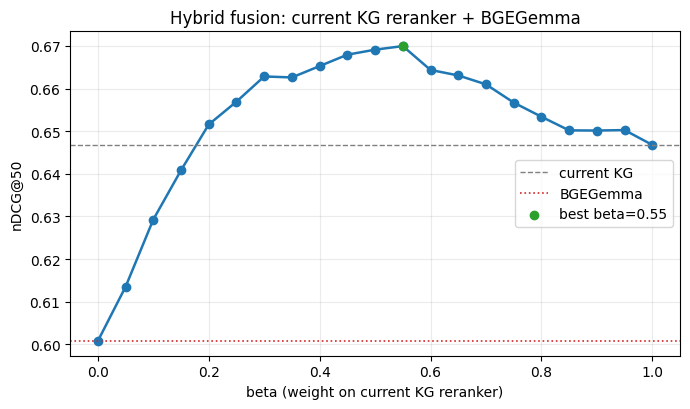

,beta,nDCG,Delta,%,MRR,P,R,F1,MAP
0,0.00,0.6008,0.1002,20.0152,0.9111,0.5187,0.4521,0.4831,0.3667
1,0.05,0.6135,0.1129,22.5564,0.9556,0.5307,0.4595,0.4925,0.3794
2,0.10,0.6293,0.1287,25.7058,0.9556,0.5413,0.4686,0.5024,0.3925
3,0.15,0.6408,0.1402,28.0143,0.9500,0.5547,0.4776,0.5133,0.4059
4,0.20,0.6516,0.1510,30.1596,0.9500,0.5613,0.4822,0.5188,0.4151
5,0.25,0.6569,0.1563,31.2289,0.9467,0.5667,0.4853,0.5228,0.4208
6,0.30,0.6628,0.1622,32.4093,0.9444,0.5733,0.4899,0.5283,0.4265
7,0.35,0.6626,0.1620,32.3635,0.9444,0.5720,0.4886,0.5270,0.4296
8,0.40,0.6653,0.1647,32.8958,0.9444,0.5733,0.4897,0.5282,0.4325
9,0.45,0.6679,0.1673,33.4296,0.9417,0.5747,0.4908,0.5295,0.4341



Best row:

                                  Method    nDCG    Delta         %      MRR     P        R       F1      MAP  beta
dense@100>>Hybrid(KG+BGE,beta=0.55)->@50 0.66996 0.169364 33.832534 0.940741 0.576 0.492507 0.530991 0.434931  0.55

Summary:

current_kg_ndcg=0.646782
bgegemma_ndcg=0.600791
best_beta=0.55
best_hybrid_ndcg=0.669960
improvement_vs_current=+0.023179
improvement_vs_bge=+0.069169
n_betas=21
used_dim=512
explained_variance=0.772856

Saved: /Users/user/Submissions/BEA-2026/artifacts/kg_bge_hybrid/kg_bge_hybrid_metrics_raw.csv
Saved: /Users/user/Submissions/BEA-2026/artifacts/kg_bge_hybrid/kg_bge_hybrid_table1_compare.csv
Saved: /Users/user/Submissions/BEA-2026/artifacts/kg_bge_hybrid/kg_bge_hybrid_by_beta.csv
Saved: /Users/user/Submissions/BEA-2026/artifacts/kg_bge_hybrid/kg_bge_hybrid_best_row.csv
Saved: /Users/user/Submissions/BEA-2026/artifacts/kg_bge_hybrid/kg_bge_hybrid_best_run.csv
Saved: /Users/user/Submissions/BEA-2026/artifacts/kg_bge_hybrid/kg_bge_hybrid_

In [4]:
dense_cache = CACHE_DIR / "dense100_run.csv"
if dense_cache.exists():
    dense_run = pd.read_csv(dense_cache)
    print("Loaded cached dense run:", dense_cache)
else:
    dense100 = FaissDenseRetriever(corpus, model_name=DENSE_MODEL, topk=K_CAND)
    dense_run = dense100.transform(topics)
    dense_run.to_csv(dense_cache, index=False)
    print("Saved dense run:", dense_cache)

dense_run = ensure_run(dense_run)
dense_source = StaticRunSource(dense_run)
cut50 = cut_k(K_FINAL)

doc_skills_df = pd.read_csv(CACHE_DIR / "doc_skills_df.csv")
qid_skills_df = pd.read_csv(CACHE_DIR / "qid_skills_df.csv")
doc_skills_df["w"] = doc_skills_df["w"].astype(float)
qid_skills_df["w"] = qid_skills_df["w"].astype(float)

doc_base = doc_skills_df[doc_skills_df["w"] >= 0.45].sort_values(["docno", "w"], ascending=[True, False]).groupby("docno", sort=False).head(15).reset_index(drop=True)
qid_base = qid_skills_df[qid_skills_df["w"] >= 0.45].sort_values(["qid", "w"], ascending=[True, False]).groupby("qid", sort=False).head(20).reset_index(drop=True)

docno2kg, qid2kg, explained, used_dim = build_svd_vectors(doc_base, qid_base, SVD_DIM)
print("used_dim:", used_dim)
print("explained_variance:", explained)

current100_path = OUT_DIR / "current_best_dense100_scores.csv"
if current100_path.exists():
    current100 = pd.read_csv(current100_path)
    print("Loaded current-best dense100 scores")
else:
    current100 = KGReranker(qid2kg, docno2kg, alpha=ALPHA).transform(dense_run)
    current100.to_csv(current100_path, index=False)
    print("Saved current-best dense100 scores")

bge100_path = OUT_DIR / "bgegemma_dense100_scores.csv"
if bge100_path.exists():
    bge100 = pd.read_csv(bge100_path)
    print("Loaded BGEGemma dense100 scores")
else:
    add_query = add_query_col(topics)
    bge_reranker = BGEGemmaReranker(corpus, model_name=BGE_MODEL, batch_size=BGE_BATCH, max_length=BGE_MAX_LENGTH)
    bge100 = (dense_source >> add_query >> bge_reranker).transform(topics)
    bge100.to_csv(bge100_path, index=False)
    print("Saved BGEGemma dense100 scores")

current100 = ensure_run(current100)
bge100 = ensure_run(bge100)

curr = current100[["qid", "docno", "score"]].rename(columns={"score": "current_score"})
bge = bge100[["qid", "docno", "score"]].rename(columns={"score": "bge_score"})
combo = curr.merge(bge, on=["qid", "docno"], how="inner")
assert len(combo) == len(curr) == len(bge), (len(combo), len(curr), len(bge))

combo = minmax_normalize_per_query(combo, "current_score", "current_norm")
combo = minmax_normalize_per_query(combo, "bge_score", "bge_norm")

rows = []
best_run = None
best_ndcg = -1.0
best_beta = None
fused_runs = {}

for beta in BETAS:
    fused = combo.copy()
    fused["score"] = beta * fused["current_norm"].astype(float) + (1.0 - beta) * fused["bge_norm"].astype(float)
    fused = fused.sort_values(["qid", "score"], ascending=[True, False]).copy()
    fused["rank"] = fused.groupby("qid").cumcount() + 1
    fused = fused[["qid", "docno", "score", "rank"]]
    fused_runs[beta] = fused

pipelines = [
    ("ANN@100->@50", dense_source >> cut50),
    (f"dense@100>>KG(SVD sim-only @512,alpha={ALPHA:.2f})->@50", StaticRunSource(current100) >> cut50),
    ("dense@100>>BGEGemma(rescore)->@50", StaticRunSource(bge100) >> cut50),
]
for beta in BETAS:
    pipelines.append((f"dense@100>>Hybrid(KG+BGE,beta={beta:.2f})->@50", StaticRunSource(fused_runs[beta]) >> cut50))

metrics_df = eval_at_k(pipelines, topics, qrels, K_FINAL)
table_df = to_table1_style(metrics_df, ann_name="ANN@100->@50", k_eval=K_FINAL)
table_df = table_df.sort_values("nDCG", ascending=False).reset_index(drop=True)

hybrid_rows = table_df[table_df["Method"].str.contains("Hybrid\(KG\+BGE", regex=True)].copy()
hybrid_rows["beta"] = hybrid_rows["Method"].str.extract(r"beta=([0-9.]+)").astype(float)
hybrid_rows = hybrid_rows.sort_values("beta").reset_index(drop=True)

best_row = hybrid_rows.sort_values("nDCG", ascending=False).iloc[0].copy()
best_beta = float(best_row["beta"])
best_ndcg = float(best_row["nDCG"])
best_run = fused_runs[best_beta]

current_row = table_df[table_df["Method"] == f"dense@100>>KG(SVD sim-only @512,alpha={ALPHA:.2f})->@50"].iloc[0]
bge_row = table_df[table_df["Method"] == "dense@100>>BGEGemma(rescore)->@50"].iloc[0]

metrics_path = OUT_DIR / "kg_bge_hybrid_metrics_raw.csv"
compare_path = OUT_DIR / "kg_bge_hybrid_table1_compare.csv"
hybrid_path = OUT_DIR / "kg_bge_hybrid_by_beta.csv"
best_row_path = OUT_DIR / "kg_bge_hybrid_best_row.csv"
best_run_path = OUT_DIR / "kg_bge_hybrid_best_run.csv"
summary_path = OUT_DIR / "kg_bge_hybrid_summary.txt"
plot_path = OUT_DIR / "kg_bge_hybrid_ndcg.png"

metrics_df.to_csv(metrics_path, index=False)
table_df.to_csv(compare_path, index=False)
hybrid_rows.to_csv(hybrid_path, index=False)
pd.DataFrame([best_row]).to_csv(best_row_path, index=False)
best_run.to_csv(best_run_path, index=False)

summary_lines = [
    f"current_kg_ndcg={float(current_row['nDCG']):.6f}",
    f"bgegemma_ndcg={float(bge_row['nDCG']):.6f}",
    f"best_beta={best_beta:.2f}",
    f"best_hybrid_ndcg={best_ndcg:.6f}",
    f"improvement_vs_current={best_ndcg - float(current_row['nDCG']):+.6f}",
    f"improvement_vs_bge={best_ndcg - float(bge_row['nDCG']):+.6f}",
    f"n_betas={len(BETAS)}",
    f"used_dim={used_dim}",
    f"explained_variance={explained:.6f}",
]
summary_path.write_text("\n".join(summary_lines), encoding="utf-8")

plt.figure(figsize=(7.0, 4.2))
plt.plot(hybrid_rows['beta'], hybrid_rows['nDCG'], marker='o', linewidth=1.8)
plt.axhline(float(current_row['nDCG']), color='gray', linestyle='--', linewidth=1.0, label='current KG')
plt.axhline(float(bge_row['nDCG']), color='tab:red', linestyle=':', linewidth=1.2, label='BGEGemma')
plt.scatter([best_beta], [best_ndcg], color='tab:green', zorder=3, label=f'best beta={best_beta:.2f}')
plt.xlabel('beta (weight on current KG reranker)')
plt.ylabel('nDCG@50')
plt.title('Hybrid fusion: current KG reranker + BGEGemma')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig(plot_path, dpi=160)
plt.show()

display(hybrid_rows[["beta", "nDCG", "Delta", "%", "MRR", "P", "R", "F1", "MAP"]].round(4))
print("\nBest row:\n")
print(pd.DataFrame([best_row]).to_string(index=False))
print("\nSummary:\n")
print("\n".join(summary_lines))
print("\nSaved:", metrics_path)
print("Saved:", compare_path)
print("Saved:", hybrid_path)
print("Saved:", best_row_path)
print("Saved:", best_run_path)
print("Saved:", summary_path)
print("Saved:", plot_path)
